# Product Shopping Agent — Ordinary Function Tools

This notebook implements a shopping assistant with two ordinary Google ADK function tools. One discovers product candidates, and the other retrieves authoritative details for one product ID.

> **Tracing notice:** automatic instrumentation sends prompts, model activity, tool arguments, and tool results to the configured Arize Phoenix project. Use only the supplied product examples and classroom prompts.

## Goal

By the end, you can explain:

1. why search and product details are separate capabilities;
2. how ADK turns typed Python functions and docstrings into model-visible tools;
3. how one conversation can produce search → details → final answer; and
4. how that trajectory appears in Phoenix.

```text
User → ADK agent → search_products     → product service
                 → get_product_details → product service
                 → grounded comparison
```

## Setup

### 1. Install the libraries

Run this once for the current kernel. The version range keeps this lesson on the Google ADK 2.x Agent Skills API used by the examples.

If Jupyter asks for a kernel restart, restart it and continue with the participant setup cell.

In [1]:
%pip install -q "google-adk[extensions]>=2.5.0,<3" "arize-phoenix-otel>=0.16.0" \
    openinference-instrumentation-google-adk \
    openinference-instrumentation-google-genai \
    google-genai httpx python-dotenv nbformat

Note: you may need to restart the kernel to use updated packages.


### 2. Create the environment file

Replace the placeholder values below, then run the cell. The `.env` file is ignored by Git, so credentials stay out of the notebook itself.

Use your name or another unique value for `PHOENIX_PROJECT_NAME` so your traces are easy to find.

In [2]:
%%writefile .env
GOOGLE_API_KEY=your-google-api-key
PHOENIX_API_KEY=your-phoenix-api-key
PHOENIX_PROJECT_NAME=your-name
PHOENIX_COLLECTOR_ENDPOINT=https://app.phoenix.arize.com/s/adk-demo-search

Writing .env


### 3. Set the notebook values

The notebook uses the credentials from the wiki cell and works when started from either the repository root or `notebooks/`.

In [3]:
import os
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()


REPOSITORY_ROOT = Path.cwd().resolve()
if REPOSITORY_ROOT.name == "notebooks":
    REPOSITORY_ROOT = REPOSITORY_ROOT.parent

PROJECT_NAME = os.environ["PHOENIX_PROJECT_NAME"]
GOOGLE_MODEL = os.getenv("GOOGLE_MODEL", "gemini-3.1-flash-lite")
print(f"Using {GOOGLE_MODEL} with Phoenix project {PROJECT_NAME!r}.")

Using gemini-3.1-flash-lite with Phoenix project 'product-notebook-saved-output-20260721'.


### 4. Enable Phoenix tracing

A **span** records one operation, such as a model request or tool execution. Related spans form a **trace**. The instrumentors below automatically connect Google GenAI and Google ADK operations to Phoenix.

Run this cell once per kernel. The guard prevents duplicate instrumentation when a cell is rerun.

In [4]:
from openinference.instrumentation.google_adk import GoogleADKInstrumentor
from openinference.instrumentation.google_genai import GoogleGenAIInstrumentor
from phoenix.otel import register

os.environ["PHOENIX_PROJECT_NAME"] = PROJECT_NAME
os.environ.setdefault(
    "PHOENIX_COLLECTOR_ENDPOINT",
    "https://app.phoenix.arize.com/s/adk-demo-search",
)
os.environ.setdefault("GOOGLE_GENAI_USE_VERTEXAI", "FALSE")

if "_PHOENIX_TRACER_PROVIDER" not in globals():
    _PHOENIX_TRACER_PROVIDER = register(
        project_name=PROJECT_NAME,
        batch=True,
    )
    GoogleGenAIInstrumentor().instrument(
        tracer_provider=_PHOENIX_TRACER_PROVIDER
    )
    GoogleADKInstrumentor().instrument(
        tracer_provider=_PHOENIX_TRACER_PROVIDER
    )

tracer_provider = _PHOENIX_TRACER_PROVIDER
print(f"Phoenix tracing enabled for project={PROJECT_NAME!r}.")

🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: product-notebook-saved-output-20260721
|  Span Processor: BatchSpanProcessor
|  Collector Endpoint: https://app.phoenix.arize.com/s/adk-demo-search/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {'authorization': '****'}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



/home/npatta01/anaconda3/lib/python3.13/site-packages/phoenix/otel/otel.py:520: UserWarning: Could not infer collector endpoint protocol, defaulting to HTTP.
  warnings.warn("Could not infer collector endpoint protocol, defaulting to HTTP.")


Phoenix tracing enabled for project='product-notebook-saved-output-20260721'.


## Steps

### Step 1 — import the two ordinary Python capabilities

A **function tool** is a normal typed Python function that ADK makes available to the model. The function does the real work; the model only proposes its name and arguments.

To keep the comparison with the next notebook fair, both lessons use the same instructor-authored API client file. This notebook imports only its functions—it does not load the surrounding skill or read `SKILL.md`.

In [5]:
import sys

SKILL_SCRIPT_DIR = (
    REPOSITORY_ROOT / "skills" / "product-shopping" / "scripts"
)
if str(SKILL_SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SKILL_SCRIPT_DIR))

from product_catalog import (
    get_product_details,
    search_products,
)

print("Imported:", search_products.__name__, "and", get_product_details.__name__)

Imported: search_products and get_product_details


### Step 2 — inspect the API boundary before adding an agent

Search returns a bounded candidate list with IDs, prices, ratings, and review counts. Product details accepts one numeric ID and returns fields such as availability, seller, brand, and specifications.

Running ordinary Python first separates API behavior from later model behavior. The first candidate is used only to demonstrate the detail response shape.

In [6]:
preview_search = search_products("55-inch 4K TV under $400")
preview_products = preview_search["products"]

preview_rows = [
    {
        key: product.get(key)
        for key in ("product_id", "name", "price", "rating", "review_count")
    }
    for product in preview_products[:3]
]
preview_rows

[{'product_id': '5534601509',
  'name': 'Westinghouse 43" QLED 4K UHD Smart TV with Roku TV, Edgeless, Dolby Vision Sound, WiFi, Voice Remote',
  'price': 259.99,
  'rating': 4.7,
  'review_count': 471},
 {'product_id': '18706053910',
  'name': 'Open Box Vizio 55" Class 4K (2160p) Smart LED TV (V4K55C-0801)',
  'price': 187.2,
  'rating': 3.8,
  'review_count': 15},
 {'product_id': '18063259062',
  'name': 'TCL 55" QM51L Series QD-Mini LED 4K QLED UHD HDR Smart Google TV (NEW 2026) - New Halo Control System, Local Dimming Pro, High Brightness Pro, TCL AIPQ Processor, Game Accelerator 144 - 55QM51L',
  'price': 398.0,
  'rating': None,
  'review_count': 0}]

#### Retrieve the full record for one qualifying candidate

Use the first result's product ID to call the second function and inspect its richer response.

In [7]:
preview_product_id = str(preview_products[0]["product_id"])
preview_details = get_product_details(preview_product_id)
{
    key: preview_details.get(key)
    for key in (
        "product_id",
        "name",
        "brand",
        "seller",
        "availability",
        "specifications",
    )
}

{'product_id': '5534601509',
 'name': 'Westinghouse 43" QLED 4K UHD Smart TV with Roku TV, Edgeless, Dolby Vision Sound, WiFi, Voice Remote',
 'brand': 'Westinghouse',
 'seller': 'Westinghouse Electronics',
 'availability': 'in_stock',
 'specifications': {'Sound technology': 'Dolby Atmos',
  'Platform': 'Roku TV',
  'Video streaming quality': 'UHD',
  'Accessories included': 'Power Cable, Remote Control, Remote Battery AAA, Stand, Screws for Stand, Quick Start Guide, Warranty Card, Tech Support Card',
  'HDMI number': '3',
  'Vertical viewing angle': '178 º',
  'High dynamic range format': 'Dolby Vision, HDR10, HLG',
  'Refresh rate': '60 Hz',
  'Smart tech': 'Y',
  'Display backlight type': 'Direct Lit',
  'Horizontal viewing angle': '178 º',
  'Television type': 'QLED TVs',
  'Number of speakers': '2',
  'Wireless technology': 'Wi-Fi',
  'Vesa mounting pattern': '300 x 300',
  'Model': 'WR43QX400',
  'Streamers': 'Roku',
  'Display': 'LED',
  'Brand': 'Westinghouse',
  'Screen size':

### Step 3 — register both functions on an ADK agent

The system instruction gives the agent a broad role. The tool names and docstrings provide the details it uses to decide what to call.

The instruction is deliberately concise so you can observe the agent's choices rather than prescribe its path.

In [8]:
from google.adk.agents import Agent
from google.adk.runners import InMemoryRunner

SYSTEM_INSTRUCTION = (
    "You are a helpful shopping assistant. "
    "Use the available tools when needed and base your answer on their results."
)

shopping_agent = Agent(
    name="product_function_tools_agent",
    model=GOOGLE_MODEL,
    instruction=SYSTEM_INSTRUCTION,
    tools=[search_products, get_product_details],
)
function_tools_runner = InMemoryRunner(
    agent=shopping_agent,
    app_name="product_function_tools_phoenix",
)
print("Function-tools agent ready.")

Function-tools agent ready.


### Run turn 1 — discover two candidates

A **session** is the conversation record ADK carries across turns. The first request should search for candidates and preserve the selected product IDs in the conversation.

Before running the cell, predict which capability the agent needs first.

In [9]:
FIRST_PROMPT = 'Find two highly rated 55-inch 4K TVs under $400. Show me the two strongest matches, prioritizing rating and number of reviews.'

await function_tools_runner.run_debug(
    FIRST_PROMPT,
    session_id='product-function-tools-session',
    verbose=True,
)

/home/npatta01/anaconda3/lib/python3.13/site-packages/google/adk/tools/function_tool.py:96: UserWarning: [EXPERIMENTAL] feature FeatureName.JSON_SCHEMA_FOR_FUNC_DECL is enabled.
  build_function_declaration(


product_function_tools_agent > [Calling tool: search_products({'query': '55-inch 4K TV under $400'})]


product_function_tools_agent > [Tool result: {'query': '55-inch 4k tv under $400', 'count': 9, 'products': [{'url': 'https://www.walmart.com/ip/W...]


product_function_tools_agent > Based on your requirements, here are two highly rated 55-inch 4K TVs currently priced under $400:

1.  **TCL 55" Q Series QLED 4K UHD HDR Smart Google TV (55Q51K)**
    *   **Price:** $248.00
    *   **Rating:** 4.4/5 stars
    *   **Number of Reviews:** 11,451
    *   **Highlights:** Features Dolby Vision, Dolby Atmos, Motion Rate 240, HDR 10+, and Auto Game Mode. This is a very strong option given its high volume of customer feedback and competitive price.

2.  **Hisense 55" M7 Series Mini-LED QLED 4K UHD Google Smart TV (55M7SG)**
    *   **Price:** $318.00
    *   **Rating:** 4.7/5 stars
    *   **Number of Reviews:** 80
    *   **Highlights:** Offers advanced Mini-LED technology, Full Array Local Dimming, and a built-in subwoofer. While it has fewer reviews than the TCL, it holds a higher rating and includes premium panel technology.

These selections prioritize a balance between affordability, high customer ratings, and reliable performance.


[Event(model_version='gemini-3.1-flash-lite', content=Content(
   parts=[
     Part(
       function_call=FunctionCall(
         args={
           'query': '55-inch 4K TV under $400'
         },
         id='TLg53LN6',
         name='search_products'
       ),
       thought_signature=b'\x124\n2\x01\x11M2\x0f^;5L4\xf7\xce\x8c\x9c\x80}\x86(\xc1\xa0"/\x86\xe5\x1a\xa0\x13r_\x05\xc7@\n\x1f\xa5\x94%\xb6\xffj\xb4\xe4XJ\t\xc1\x99\xc9\x11{'
     ),
   ],
   role='model'
 ), grounding_metadata=None, partial=None, turn_complete=None, turn_complete_reason=None, finish_reason=<FinishReason.STOP: 'STOP'>, error_code=None, error_message=None, interrupted=None, custom_metadata=None, usage_metadata=GenerateContentResponseUsageMetadata(
   candidates_token_count=28,
   prompt_token_count=245,
   prompt_tokens_details=[
     ModalityTokenCount(
       modality=<MediaModality.TEXT: 'TEXT'>,
       token_count=245
     ),
   ],
   total_token_count=273
 ), live_session_resumption_update=None, live_session

### Phoenix trace — Turn 1

The first trace shows what the model knew about the tools, the search call it chose, and the candidate response it produced.

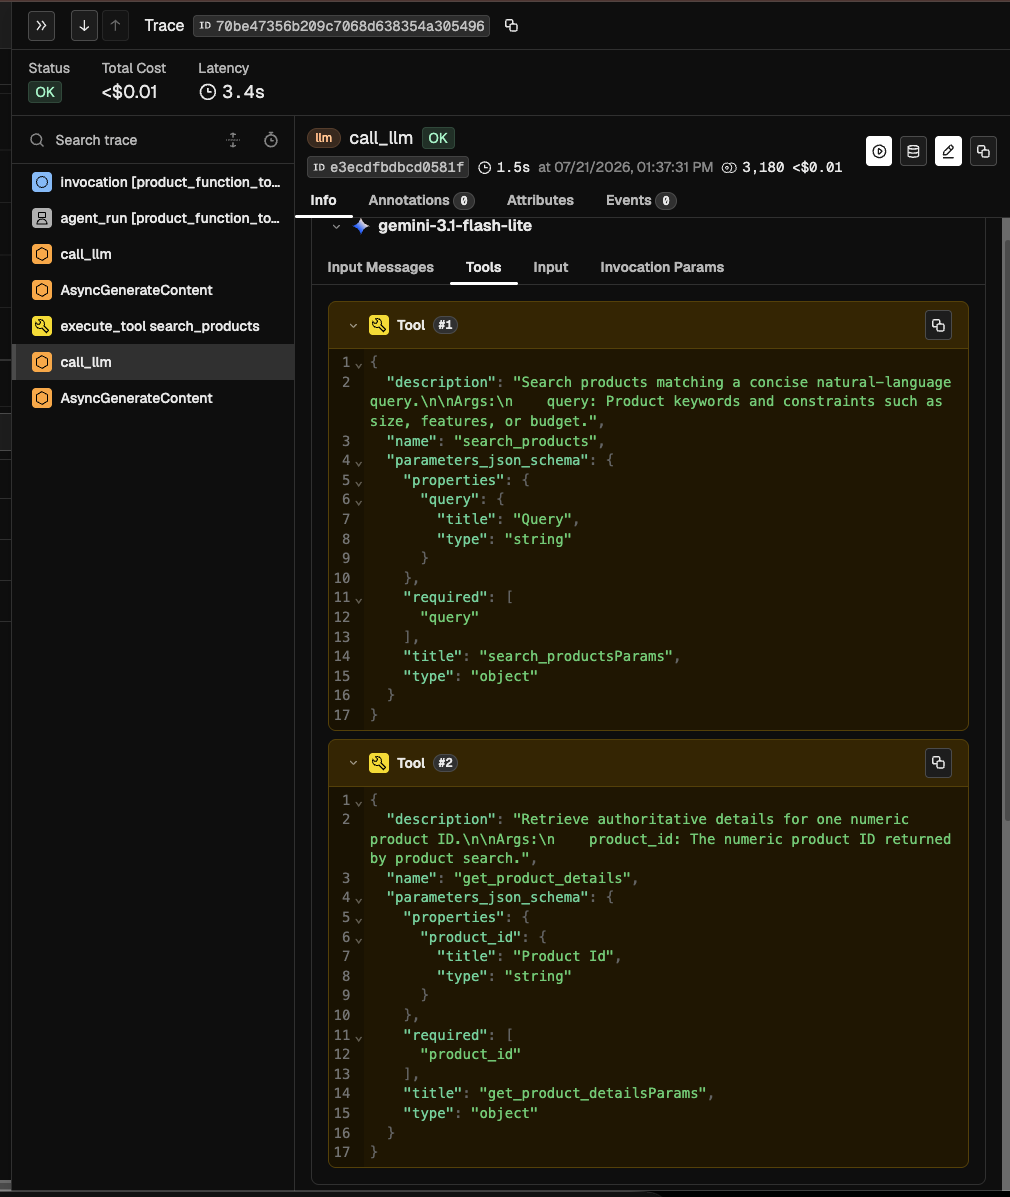

*The function names, type hints, and docstrings become model-visible tool schemas.*

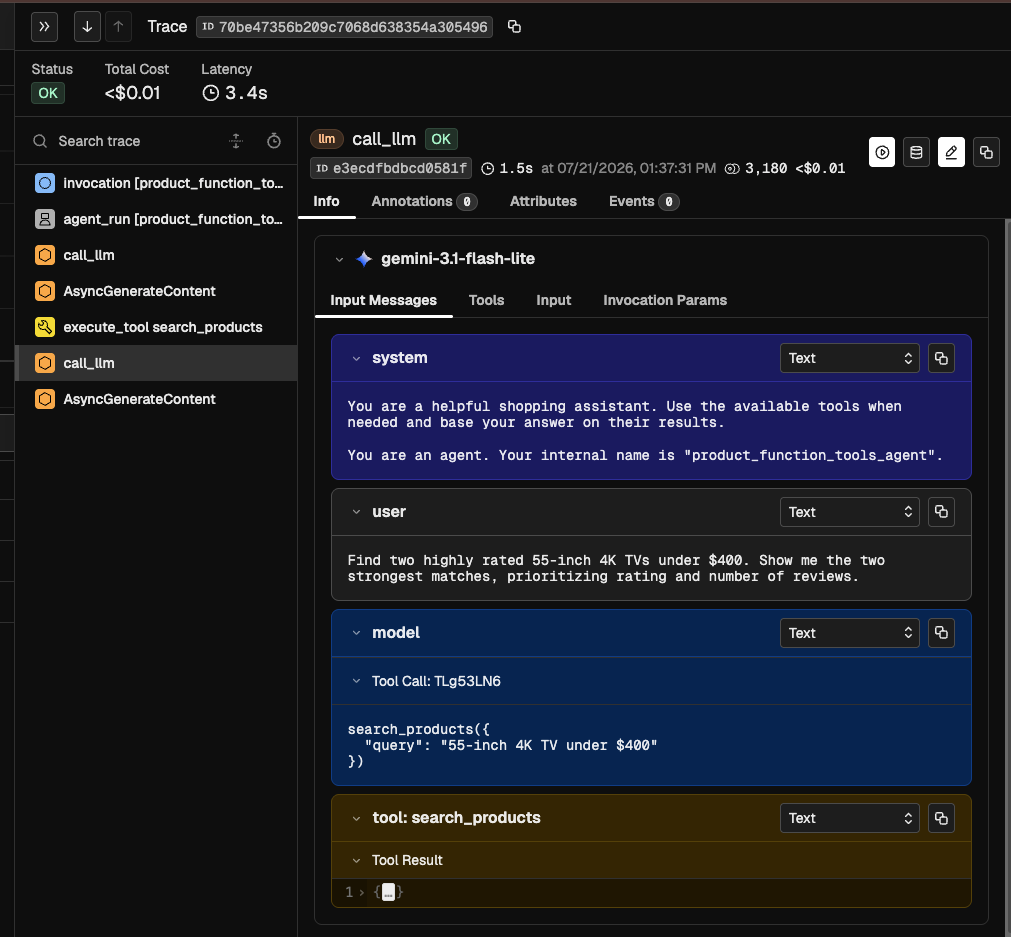

*The model translates the request into one `search_products` call.*

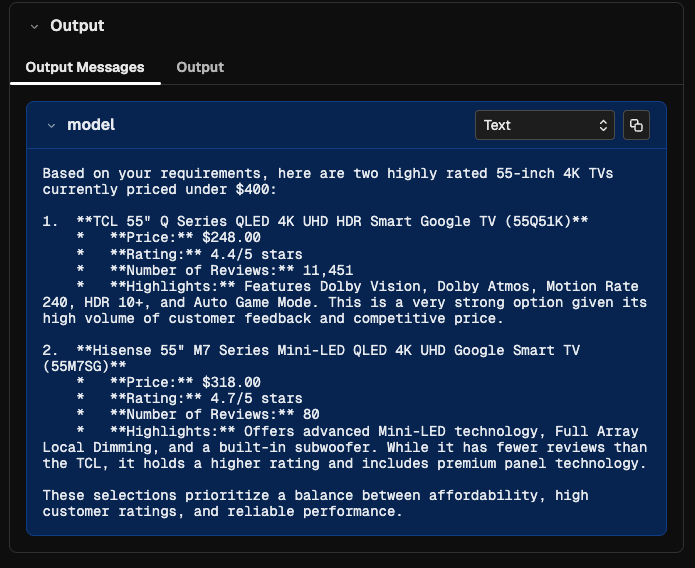

*The first turn returns two candidates grounded in the search result.*

### Run turn 2 — retrieve details and compare

“Those two” depends on the session history. Search results contain enough information to shortlist products, while the detail operation adds seller, availability, brand, description, and specifications.

Before running the cell, predict how many detail lookups a grounded comparison requires.

In [10]:
SECOND_PROMPT = 'Compare those two using their full product details. Compare availability, seller, brand, and key specifications, then recommend one. Clearly identify any missing information.'

await function_tools_runner.run_debug(
    SECOND_PROMPT,
    session_id='product-function-tools-session',
    verbose=True,
)

product_function_tools_agent > [Calling tool: get_product_details({'product_id': '14566603957'})]


product_function_tools_agent > [Tool result: {'category_path': '/cp/all-smart-tvs/1229817', 'availability': 'in_stock', 'rating': 4.4, 'currency'...]


product_function_tools_agent > [Calling tool: get_product_details({'product_id': '19117160038'})]


product_function_tools_agent > [Tool result: {'category_path': '/cp/all-smart-tvs/1229817', 'availability': 'in_stock', 'rating': 4.7, 'currency'...]


product_function_tools_agent > Here is a detailed comparison of the two 55-inch 4K TVs.

### Comparison Table

| Feature | TCL 55Q51K (Q Series) | Hisense 55M7SG (M7 Series) |
| :--- | :--- | :--- |
| **Price** | $248.00 | $318.00 |
| **Display Tech** | QLED | Mini-LED QLED |
| **Peak Brightness** | Not specified | Up to 1000 nits |
| **HDR Formats** | Dolby Vision, HDR10+, HLG | Dolby Vision IQ, HDR10+ Adaptive, etc. |
| **HDMI Ports** | 3 | 4 |
| **Audio** | Dolby Atmos, DTS Virtual:X | Dolby Atmos, Built-in Subwoofer |
| **Refresh Rate** | 60 Hz | 60 Hz |
| **Smart Platform** | Google TV | Google TV |
| **Rating** | 4.4 / 5 (11,451 reviews) | 4.7 / 5 (80 reviews) |
| **Seller** | Walmart.com | Walmart.com |

---

### Analysis

*   **Display Quality:** The **Hisense M7** is the clear winner regarding display technology. By using Mini-LED, it offers significantly better contrast, deeper blacks, and higher peak brightness (1000 nits) compared to the standard QLED panel on the TCL Q51K.

[Event(model_version='gemini-3.1-flash-lite', content=Content(
   parts=[
     Part(
       function_call=FunctionCall(
         args={
           'product_id': '14566603957'
         },
         id='MYx9s2AN',
         name='get_product_details'
       ),
       thought_signature=b'\x124\n2\x01\x11M2\x0f\xa03\xb0`\xbc\x8f\x0e\xb7\xe6!\x9e\xb2.\xdfBuY)\x01\xdd\x98e\x9c\xf0n\x02$\xbay\x8d\xb0b\x7f\x9d\x16\x90[\xff\x9a\xb2\xa0\x8c\x03\xab\x87'
     ),
   ],
   role='model'
 ), grounding_metadata=None, partial=None, turn_complete=None, turn_complete_reason=None, finish_reason=<FinishReason.STOP: 'STOP'>, error_code=None, error_message=None, interrupted=None, custom_metadata=None, usage_metadata=GenerateContentResponseUsageMetadata(
   candidates_token_count=30,
   prompt_token_count=3212,
   prompt_tokens_details=[
     ModalityTokenCount(
       modality=<MediaModality.TEXT: 'TEXT'>,
       token_count=3212
     ),
   ],
   total_token_count=3242
 ), live_session_resumption_update=None, 

### Phoenix trace — Turn 2

The follow-up trace shows the retained conversation context, two detail lookups, and the grounded comparison.

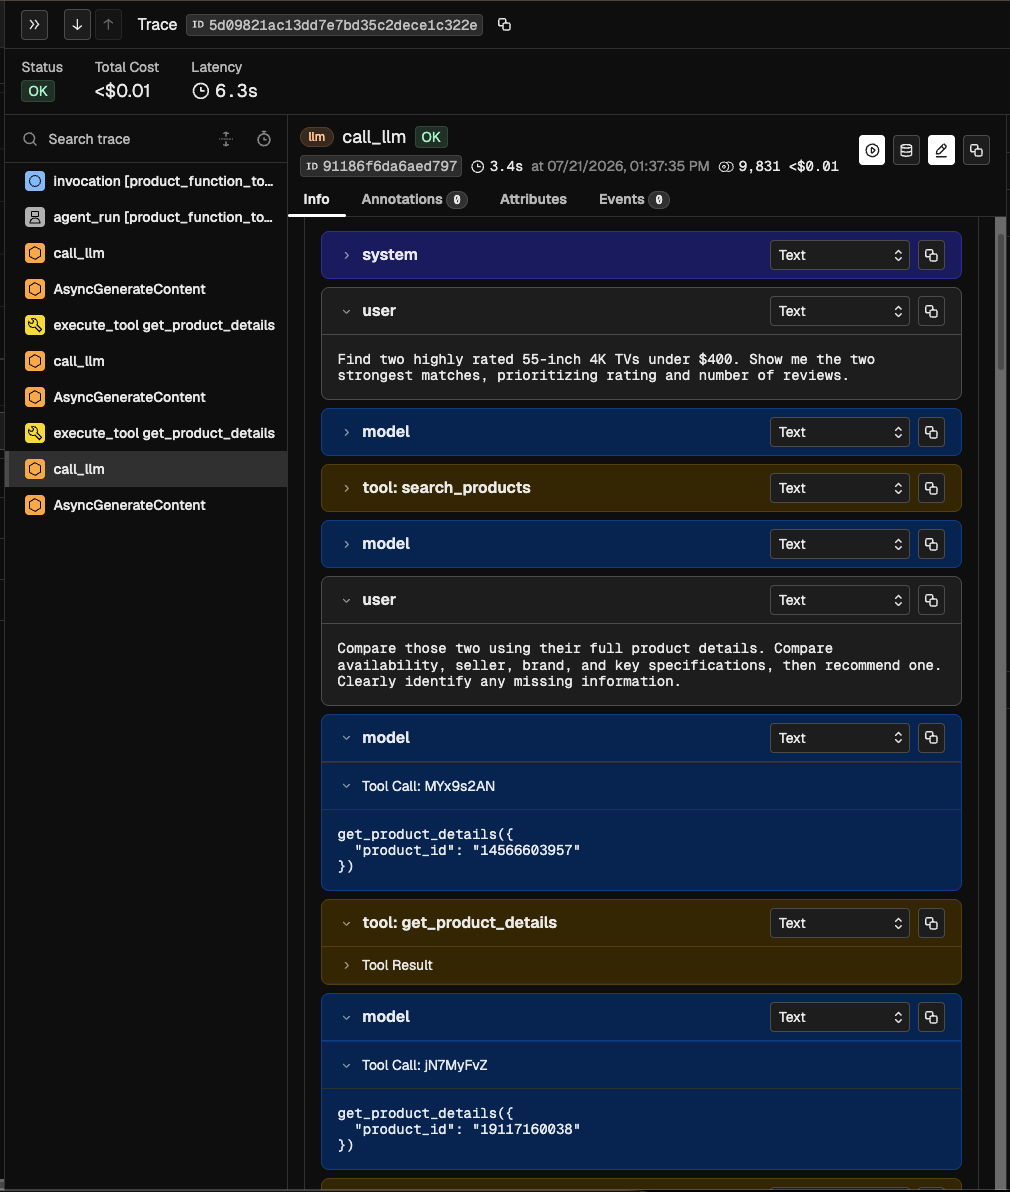

*The agent reuses both product IDs from Turn 1 and retrieves each full record.*

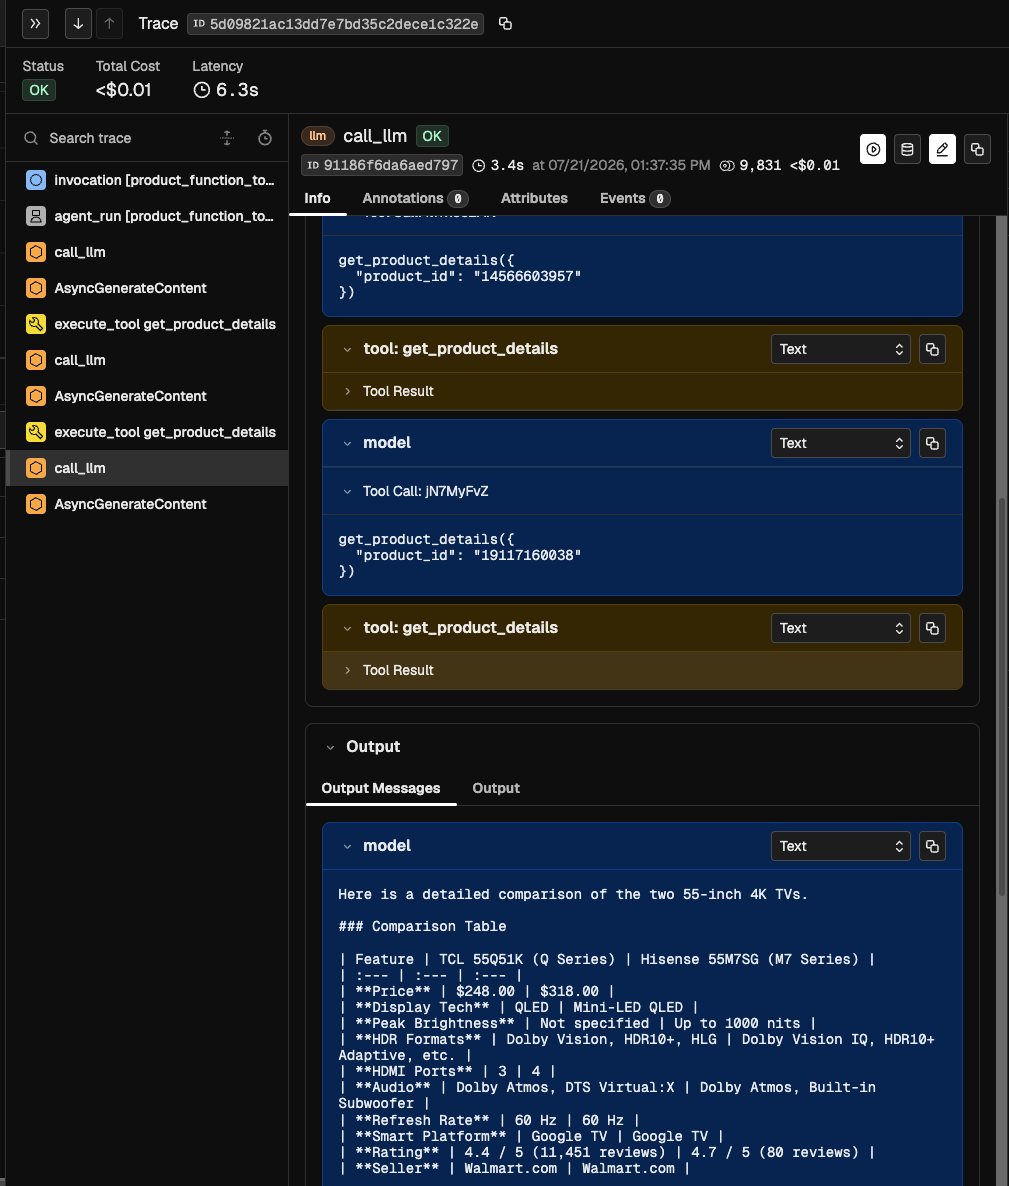

*The final recommendation is synthesized from the two detailed records.*

## Checks

### Flush the latest spans

Phoenix batches telemetry in the background. Flushing ensures the latest model and tool spans leave the notebook process before you open the trace explorer.

In [11]:
tracer_provider.force_flush()
print(f"Traces flushed to Phoenix project {PROJECT_NAME!r}.")

Traces flushed to Phoenix project 'product-notebook-saved-output-20260721'.


### What to notice in Phoenix

            Open your configured Phoenix project and inspect the two ADK turns. Model behavior is nondeterministic, so treat the expected path as a hypothesis and verify the actual spans.

            | Evidence | What it demonstrates |
            | --- | --- |
            | `search_products` span | The model translated the first request into a search query. |
| Two `get_product_details` spans | The model reused product IDs from the session and retrieved both complete records. |
            | Second model response | The final recommendation is synthesized from returned data rather than invented facts. |

            Ask three questions while reading the trace:

            1. Which fields came from search, and which required full product details?
            2. Where did the product IDs move from one operation to the next?
            3. Did the final answer clearly identify missing data?

## Next Steps

1. Change the budget and inspect how the selected candidates change.
2. Ask about a specification absent from both detail records. Does the agent admit the gap?
3. Run the follow-up with a new session ID. What does “those two” refer to now?
4. Continue to Notebook 3 to package the same shopping capability as one Agent Skill.

Primary references:

- [Google ADK documentation](https://google.github.io/adk-docs/)
- [Phoenix tracing documentation](https://arize.com/docs/phoenix/tracing/how-to-tracing/setup-tracing)